In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import os
import warnings
from matplotlib.gridspec import GridSpec
warnings.filterwarnings('ignore')
from scipy.interpolate import RegularGridInterpolator, griddata
from scipy.stats import pearsonr
from datetime import datetime, timedelta
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER 
from concurrent.futures import ProcessPoolExecutor, as_completed
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.optimize import curve_fit

def add_bottom_cax_big (ax0, ax3, pad, width) :#pad控制颜色条与 ax0 之间的间距
    axpos1=ax0. get_position ( )
    axpos2=ax3. get_position ( )
    caxpos = mpl.transforms.Bbox.from_extents( #Bbox.from_extents方法创建一个新的边界框
        axpos1.x0,
        axpos1.y0 - pad -width,
        axpos2.x1,
        axpos1.y0 - pad
    )
    cax=ax0.figure.add_axes(caxpos) #颜色条坐标轴
    return cax

def add_right_cax_big (ax1, ax2, pad, width) :
    axpos1=ax1. get_position ( )
    axpos2=ax2. get_position ( )
    caxpos = mpl.transforms.Bbox.from_extents(
    axpos1.x1 + pad,
    axpos2.y0,
    axpos1.x1 + pad + width,
    axpos1.y1
    )
    cax=ax1.figure.add_axes(caxpos)
    return cax

In [2]:
def weight_mean(data, dx, dy):
    weight = dx*dy
    w = weight.copy()
    w[np.isnan(data)] = np.nan
    res = np.nansum(data*w)/np.nansum(w)
    return res

def weight_mean_3d(data, dx, dy):
    weight = dx*dy
    res = np.full_like(data[:,0,0],np.nan)
    for i in range(np.shape(data)[0]):
        w = weight.copy()
        w[np.isnan(data[i])] = np.nan
        res[i] = np.nansum(data[i,:,:]*w,axis=(-2,-1))/np.nansum(w)
    return res

def weight_mean_lat(data, w):
    w[np.isnan(np.nanmean(data,-1))] = np.nan
    res = np.nansum(data*w[:,None],axis=0)/np.nansum(w)
    return res

In [49]:
def cal_surf_rmse(date_list,version):
    sst_rmse = np.zeros(len(date_list))
    sla_rmse = np.zeros(len(date_list))
    for i in range(len(date_list)):
        date = date_list[i]
        date_s = date.replace('-','')
        if version=='pre':
            f_a = f'/data/lfs/LicomFSOne/assim/output/postprocess/analysed_state_BACK-{date}_sub-OC.nc_assim'
        else:
            f_a = f'/data/lfs/LicomFSOne/assim/output/postprocess/analysed_state_DTS-{date}_sub-OC.nc_{version}'
        res = xr.open_dataset(
            os.path.join(f_a),
            decode_times=False)
        t_o = xr.open_dataset(
            os.path.join(f'/data/lfs/LicomFSOne/assim/input/SST/{date[:4]}/ostia{date_s}.nc'),
            decode_times=False)
        new_lon = xr.where(t_o['lon'] < 0, t_o['lon'] + 360, t_o['lon'])
        t_o = t_o.assign_coords(lon=new_lon)
        t_o = t_o.sortby('lon') 

        z_o = xr.open_dataset(
            os.path.join(f'/data/lfs/LicomFSOne/assim/input/SLA/{date[:4]}/sla{date_s}.nc'),
            decode_times=False)
        new_lon = xr.where(z_o['longitude'] < 0, z_o['longitude'] + 360, z_o['longitude'])
        z_o = z_o.assign_coords(longitude=new_lon)
        z_o = z_o.sortby('longitude').interp(longitude=res.lon,latitude=res.lat)
        z_mdt = xr.open_dataset(
                    os.path.join('/data/lfs/LicomFSOne/assim/Analysis/ssh_ncdata/mdt_25km_m0.nc'),
                    decode_times=False)
        new_lon = xr.where(z_mdt['lon'] < 0, z_mdt['lon'] + 360, z_mdt['lon'])
        z_mdt = z_mdt.assign_coords(lon=new_lon)
        z_mdt = z_mdt.sortby('lon').interp(lon=res.lon.data,lat=res.lat.data)
        Lon, Lat = np.meshgrid(res.lon, res.lat)
        dx = 6371*1e3*np.pi/180*np.gradient(Lon,axis=1)*np.cos(np.radians(Lat))
        dy = 6371*1e3*np.pi/180*np.gradient(Lat,axis=0)
        sla_diff = weight_mean(res.z0[0].values-z_mdt.mdt[0].values-z_o.sla[0].values,dx,dy)
        sla_rmse[i] = np.sqrt(weight_mean(((res.z0[0].values-z_mdt.mdt[0].values-z_o.sla[0].values-sla_diff))**2,dx,dy))
        sst_rmse[i] = np.sqrt(weight_mean(((res.tt[0,0].values-t_o.analysed_sst[0].values+273.15))**2,dx,dy))
    return sst_rmse, sla_rmse

In [50]:
def cal_surf_mae(date_list,version):
    sst_mae = np.zeros((len(date_list),720,1440))
    sla_mae = np.zeros((len(date_list),720,1440))
    for i in range(len(date_list)):
        date = date_list[i]
        date_s = date.replace('-','')
        f_a = f'/data/lfs/LicomFSOne/assim/output/postprocess/analysed_state_DTS-{date}_sub-OC.nc_{version}'
        res = xr.open_dataset(
            os.path.join(f_a),
            decode_times=False)
        t_o = xr.open_dataset(
            os.path.join(f'/data/lfs/LicomFSOne/assim/input/SST/{date[:4]}/ostia{date_s}.nc'),
            decode_times=False)
        new_lon = xr.where(t_o['lon'] < 0, t_o['lon'] + 360, t_o['lon'])
        t_o = t_o.assign_coords(lon=new_lon)
        t_o = t_o.sortby('lon') 

        z_o = xr.open_dataset(
            os.path.join(f'/data/lfs/LicomFSOne/assim/input/SLA/{date[:4]}/sla{date_s}.nc'),
            decode_times=False)
        if version=='new0':
            new_lon = xr.where(z_o['longitude'] < 0, z_o['longitude'] + 360, z_o['longitude'])
        else:
            new_lon = xr.where(z_o['longitude'] <= 0, z_o['longitude'] + 360, z_o['longitude'])
        z_o = z_o.assign_coords(longitude=new_lon)
        z_o = z_o.sortby('longitude').interp(longitude=res.lon,latitude=res.lat)
        z_mdt = xr.open_dataset(
                    os.path.join('/data/lfs/LicomFSOne/assim/Analysis/ssh_ncdata/mdt_25km_m0.nc'),
                    decode_times=False)
        if version=='new0':
            new_lon = xr.where(z_mdt['lon'] < 0, z_mdt['lon'] + 360, z_mdt['lon'])
        else:
            new_lon = xr.where(z_mdt['lon'] <= 0, z_mdt['lon'] + 360, z_mdt['lon'])
        z_mdt = z_mdt.assign_coords(lon=new_lon)
        z_mdt = z_mdt.sortby('lon').interp(lon=res.lon.data,lat=res.lat.data)
        Lon, Lat = np.meshgrid(res.lon, res.lat)
        dx = 6371*1e3*np.pi/180*np.gradient(Lon,axis=1)*np.cos(np.radians(Lat))
        dy = 6371*1e3*np.pi/180*np.gradient(Lat,axis=0)
        sla_diff = weight_mean(res.z0[0].values-z_mdt.mdt[0].values-z_o.sla[0].values,dx,dy)
        sla_mae[i] = np.abs((res.z0[0].values-z_mdt.mdt[0].values-z_o.sla[0].values-sla_diff))
        sst_mae[i] = np.abs((res.tt[0,0].values-t_o.analysed_sst[0].values+273.15))
    return sst_mae, sla_mae

In [51]:
def interp_profiles_to_depth(depth_2d, var_2d, target_depth,
                             fill_value=np.nan, assume_depth_positive=True):
    depth_2d = np.asarray(depth_2d, dtype=float)
    var_2d   = np.asarray(var_2d, dtype=float)
    zt       = np.asarray(target_depth, dtype=float)
    nprof, _ = depth_2d.shape
    out = np.full((nprof, zt.size), fill_value, dtype=float)

    for i in range(nprof):
        z = depth_2d[i, :]
        v = var_2d[i, :]
        m = np.isfinite(z) & np.isfinite(v)
        if m.sum() < 2:
            continue

        z = z[m]
        v = v[m]
        if assume_depth_positive:
            z = np.abs(z)
        idx = np.argsort(z)
        z = z[idx]
        v = v[idx]
        z_unique, uniq_idx = np.unique(z, return_index=True)
        v_unique = v[uniq_idx]

        if z_unique.size < 2:
            continue
        inside = (zt >= z_unique.min()) & (zt <= z_unique.max())
        out[i, inside] = np.interp(zt[inside], z_unique, v_unique)
    return out


def rmse_argo_ts(f_obs,f_a):
    da_obs = xr.open_dataset(f_obs)  
    new_lon = xr.where(da_obs['LONGITUDE'] < 0, da_obs['LONGITUDE'] + 360, da_obs['LONGITUDE'])
    tt_lfs = xr.open_dataset(f_a,
                decode_times=False).interp(lon=new_lon,lat=da_obs.LATITUDE)['tt'].squeeze()
    ss_lfs = xr.open_dataset(f_a,
                    decode_times=False).interp(lon=new_lon,lat=da_obs.LATITUDE)['ss'].squeeze()
    tt_argo_new = interp_profiles_to_depth(da_obs.PRES_ADJUSTED, da_obs.TEMP_ADJUSTED, tt_lfs.lev.data,
                                fill_value=np.nan, assume_depth_positive=True)
    ss_argo_new = interp_profiles_to_depth(da_obs.PRES_ADJUSTED, da_obs.PSAL_ADJUSTED, ss_lfs.lev.data,
                                fill_value=np.nan, assume_depth_positive=True)
    tt_argo_qc_new = interp_profiles_to_depth(da_obs.PRES_ADJUSTED, da_obs.TEMP_ADJUSTED_QC, tt_lfs.lev.data,
                                fill_value=np.nan, assume_depth_positive=True) 
    ss_argo_qc_new = interp_profiles_to_depth(da_obs.PRES_ADJUSTED, da_obs.PSAL_ADJUSTED_QC, ss_lfs.lev.data,
                                fill_value=np.nan, assume_depth_positive=True) 
    mask_t = np.full_like(tt_argo_qc_new,np.nan)
    mask_s = np.full_like(ss_argo_qc_new,np.nan)
    mask_t[tt_argo_qc_new<=1.01] = 1
    mask_t[tt_argo_new<-1.8] = np.nan
    mask_t[tt_argo_new>35] = np.nan
    mask_s[ss_argo_qc_new<=1.01] = 1
    mask_s[ss_argo_new<28] = np.nan
    mask_s[ss_argo_new>40] = np.nan
    t_diff2 = (tt_lfs.data.T - tt_argo_new)**2*mask_t
    s_diff2 = (ss_lfs.data.T - ss_argo_new)**2*mask_s
    return da_obs.LATITUDE.data, t_diff2,s_diff2

In [52]:
def rmse_all(date,version):
    d_s = date.replace('-','')
    f_obs1=f'/data/lfs/LicomFS/assim/input/ARGO/geo/pacific_ocean/{d_s[:4]}/{d_s[4:6]}/{d_s}_prof.nc'
    f_obs2=f'/data/lfs/LicomFS/assim/input/ARGO/geo/atlantic_ocean/{d_s[:4]}/{d_s[4:6]}/{d_s}_prof.nc'
    f_obs3=f'/data/lfs/LicomFS/assim/input/ARGO/geo/indian_ocean/{d_s[:4]}/{d_s[4:6]}/{d_s}_prof.nc'
    if version=='pre':
        f_a = f'/data/lfs/LicomFSOne/assim/output/postprocess/analysed_state_BACK-{date}_sub-OC.nc_assim'
    else:
        f_a = f'/data/lfs/LicomFSOne/assim/output/postprocess/analysed_state_DTS-{date}_sub-OC.nc_{version}'
    lat1, t_d1,s_d1 = rmse_argo_ts(f_obs1,f_a)
    lat2, t_d2,s_d2 = rmse_argo_ts(f_obs2,f_a)
    lat3, t_d3,s_d3 = rmse_argo_ts(f_obs3,f_a)
    lat = np.concatenate([lat1,lat2,lat3])
    t_d = np.concatenate([t_d1,t_d2,t_d3],0)
    s_d = np.concatenate([s_d1,s_d2,s_d3],0)
    t_rmse = weight_mean_lat(t_d,lat)**.5
    s_rmse = weight_mean_lat(s_d,lat)**.5
    return t_rmse, s_rmse

In [53]:
def cal_prof_rmse(date_list, version, max_workers=None):
    n_dates = len(date_list)
    t_rmse = np.zeros((n_dates, 55))
    s_rmse = np.zeros((n_dates, 55))
    
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        # 提交所有任务
        future_to_index = {}
        for i, date in enumerate(date_list):
            future = executor.submit(rmse_all, date, version)
            future_to_index[future] = i
        
        for future in as_completed(future_to_index):
            idx = future_to_index[future]
            t_result, s_result = future.result()
            t_rmse[idx] = t_result
            s_rmse[idx] = s_result
    return t_rmse, s_rmse

In [54]:
def KE(date_list,version):
    ke = np.zeros(len(date_list))
    for i in range(len(date_list)):
        date = date_list[i]
        if version=='pre':
            f_a = f'/data/lfs/LicomFSOne/assim/output/postprocess/analysed_state_BACK-{date}_sub-OC.nc'
        else:
            f_a = f'/data/lfs/LicomFSOne/assim/output/postprocess/analysed_state_DTS-{date}_sub-OC.nc_{version}'
        res = xr.open_dataset(
            os.path.join(f_a),
            decode_times=False).sel(lev=slice(0,1000)).squeeze()
        Lon, Lat = np.meshgrid(res.lon, res.lat)
        dx = 6371*1e3*np.pi/180*np.gradient(Lon,axis=1)*np.cos(np.radians(Lat))
        dy = 6371*1e3*np.pi/180*np.gradient(Lat,axis=0)
        ke[i] = np.average(weight_mean_3d(.5*res.uu.data**2+res.vv.data**2,dx,dy), weights=np.gradient(res.lev.data))
    return ke

def thermocline_depth_gradient(temp, depth):
    dTdz = np.gradient(temp, depth, axis=0)
    idx = np.argmax(np.abs(dTdz), axis=0)
    thermo_depth = depth[idx]
    return thermo_depth

def mld_temperature(temp, depth, dT=0.2, ref_depth=2.5):
    nz, ny, nx = temp.shape
    kref = np.argmin(np.abs(depth - ref_depth))
    Tref = temp[kref]
    mld = np.full((ny, nx), np.nan)
    for k in range(kref+1, nz):
        mask = (Tref - temp[k]) >= dT
        mld[mask & np.isnan(mld)] = depth[k]

    return mld

def _diff_single(date, version):
    f_b = f'/data/lfs/LicomFSOne/assim/output/postprocess/analysed_state_BACK-{date}_sub-OC.nc_assim'
    f_a = f'/data/lfs/LicomFSOne/assim/output/postprocess/analysed_state_DTS-{date}_sub-OC.nc_{version}'
    b = xr.open_dataset(f_b, decode_times=False).sel(lat=slice(20,90)).squeeze()
    res = xr.open_dataset(f_a, decode_times=False).sel(lat=slice(20,90)).squeeze()
    lev = res.lev.data
    td = mld_temperature(res.tt.data, lev)
    Lon, Lat = np.meshgrid(res.lon, res.lat)
    dx = 6371e3*np.pi/180*np.gradient(Lon,axis=1)*np.cos(np.radians(Lat))
    dy = 6371e3*np.pi/180*np.gradient(Lat,axis=0)
    diff = weight_mean_3d(np.abs(res.tt.data - b.tt.data), dx, dy)
    Td = weight_mean(td, dx, dy)
    b.close()
    res.close()

    return diff, Td

def Diff(date_list, version):
    ndep = 55
    diff = np.zeros((len(date_list), ndep))
    td = np.zeros(len(date_list))
    workers = 24
    with ProcessPoolExecutor(max_workers=workers) as executor:
        futures = {
            executor.submit(_diff_single, date, version): i
            for i, date in enumerate(date_list)
        }
        for future in as_completed(futures):
            i = futures[future]
            diff[i],td[i] = future.result()

    return diff,td

def cal_corr(fu,fv,lon,lat,out_fname,anomaly=True):
    if anomaly:
        u = xr.open_dataset(fu)['uu'].squeeze().sel(lon=slice(lon-3,lon+8),lat=slice(lat-4,lat+4))
        clim = u.groupby('time.dayofyear').mean('time')
        u = u.groupby('time.dayofyear') - clim
        v = xr.open_dataset(fv)['vv'].squeeze().sel(lon=slice(lon-3,lon+8),lat=slice(lat-4,lat+4))
        clim = v.groupby('time.dayofyear').mean('time')
        v = v.groupby('time.dayofyear') - clim
    else:
        u = xr.open_dataset(fu)['uu'].squeeze().sel(lon=slice(lon-3,lon+8),lat=slice(lat-4,lat+4))
        v = xr.open_dataset(fv)['vv'].squeeze().sel(lon=slice(lon-3,lon+8),lat=slice(lat-4,lat+4))
    V = (u**2+v**2)**.5
    ref_series = V.interp(lon=lon, lat=lat)
    spatial_corr = xr.corr(ref_series, V, dim='time')
    spatial_corr.name = 'corr'
    spatial_corr.to_netcdf(out_fname)
    return

def sine_func_fixed_period(x, A, phi, offset):
    freq = 1/(len(x))
    return A * np.sin(2 * np.pi * freq * x + phi) + offset

def sin_fit(x,y):
    popt, _ = curve_fit(lambda x, A, phi, offset: sine_func_fixed_period(x, A, phi, offset), x, y, p0=[1, 0, 0])
    A_fit, phi_fit, offset_fit = popt
    y_fit = sine_func_fixed_period(x, A_fit, phi_fit, offset_fit)
    return y_fit


In [55]:
def generate_multi_track_outline(l3_lon, l3_lat, buffer_deg=0.25):
    points = np.vstack((l3_lon, l3_lat)).T

    diffs = np.sqrt(np.diff(l3_lon)**2 + np.diff(l3_lat)**2)
    jump_indices = np.where(diffs > 1.5)[0] + 1
    split_tracks = np.split(points, jump_indices)
    buffers = []
    for pts in split_tracks:
        if len(pts) < 2:
            continue
        track_line = LineString(pts)
        buffers.append(track_line.buffer(buffer_deg))
    
    if not buffers:
        raise ValueError("ERROR!")

    combined_buffer = unary_union(buffers)
    track_outline = combined_buffer.boundary
    return track_outline

In [56]:
# def KE Spec
def _binned_agg(
    array: np.ndarray,
    indices: np.ndarray,
    num_bins: int,
    *,
    func,
    fill_value,
    dtype,
) -> np.ndarray:
    """NumPy helper function for aggregating over bins."""

    try:
        import numpy_groupies
    except ImportError:
        raise ImportError(
            "This function requires the `numpy_groupies` package to be installed. "
            + "Please install it with pip or conda."
        )

    mask = np.logical_not(np.isnan(indices))
    int_indices = indices[mask].astype(int)
    shape = array.shape[: -indices.ndim] + (num_bins,)
    result = numpy_groupies.aggregate(
        int_indices,
        array[..., mask],
        func=func,
        size=num_bins,
        fill_value=fill_value,
        dtype=dtype,
        axis=-1,
    )
    return result

def _groupby_bins_agg(
    array: xr.DataArray,
    group: xr.DataArray,
    bins,
    func="sum",
    fill_value=0,
    dtype=None,
    **cut_kwargs,
) -> xr.DataArray:
    """Faster equivalent of Xarray's groupby_bins(...).sum()."""
    # https://github.com/pydata/xarray/issues/4473
    binned = pd.cut(np.ravel(group), bins, **cut_kwargs)
    new_dim_name = group.name + "_bins"
    indices = group.copy(data=binned.codes.reshape(group.shape))

    result = xr.apply_ufunc(
        _binned_agg,
        array,
        indices,
        input_core_dims=[indices.dims, indices.dims],
        output_core_dims=[[new_dim_name]],
        output_dtypes=[array.dtype],
        dask_gufunc_kwargs=dict(
            allow_rechunk=True,
            output_sizes={new_dim_name: binned.categories.size},
        ),
        kwargs={
            "num_bins": binned.categories.size,
            "func": func,
            "fill_value": fill_value,
            "dtype": dtype,
        },
        dask="parallelized",
    )
    result.coords[new_dim_name] = binned.categories
    return result

def isotropize(ps, fftdim, nfactor=4, **kwargs):
    """
    Isotropize a 2D power spectrum or cross spectrum
    by taking an azimuthal average.
    .. math::
        \text{iso}_{ps} = k_r N^{-1} \sum_{N} |\mathbb{F}(da')|^2
    where :math:`N` is the number of azimuthal bins.
    Parameters
    ----------
    ps : `xarray.DataArray`
        The power spectrum or cross spectrum to be isotropized.
    fftdim : list
        The fft dimensions overwhich the isotropization must be performed.
    nfactor : int, optional
        Ratio of number of bins to take the azimuthal averaging with the
        data size. Default is 4.
    """

    # compute radial wavenumber bins
    k = ps[fftdim[1]]
    l = ps[fftdim[0]]

    N = [k.size, l.size]
    nbins = int(min(N) / nfactor)
    freq_r = np.sqrt(k ** 2 + l ** 2).rename("freq_r")
    kr = _groupby_bins_agg(freq_r, freq_r, bins=nbins, func="mean")

    if "truncate" in kwargs:
        if truncate:
            if k.max() > l.max():
                kmax = l.max()
            else:
                kmax = k.max()
            kr = kr.where(kr <= kmax)
        else:
            pass

    iso_ps = (
        _groupby_bins_agg(ps, freq_r, bins=nbins, func="mean")
        .rename({"freq_r_bins": "freq_r"})
        .drop_vars("freq_r")
    )
    iso_ps.coords["freq_r"] = kr.data
    if "truncate" in kwargs:
        if truncate:
            return (iso_ps * iso_ps.freq_r).dropna("freq_r")
    else:
        return iso_ps * iso_ps.freq_r
    
def density(ps, dim):
    ff = np.prod([float(ps[d].spacing) for d in dim])
    return ps * ff

def iso_KES(dau,dav):
    a = 6371000
    x, y = np.meshgrid(dau.lon.data,dau.lat.data)
    coslat = np.cos(y * np.pi / 180)
    sinlat = np.sin(y * np.pi / 180)
    gx = np.gradient(x, axis=1)
    gy = np.gradient(y, axis=0)
    dx = (gx * np.pi / 180) * coslat * a
    dy = (gy * np.pi / 180) * a
    u = dau.data.copy()
    u[u>10]=np.nan
    v = dav.data.copy()
    v[v>10]=np.nan
    U = xr.DataArray(u, 
                        dims=['y','x'],
                        coords={'y':np.arange(0,len(dau.lat)*np.abs(np.mean(dy)),np.abs(np.mean(dy))),
                                'x':np.arange(0,len(dau.lon)*np.mean(dx),np.mean(dx))})
    
    V = xr.DataArray(v, 
                            dims=['y','x'],
                            coords={'y':np.arange(0,len(dau.lat)*np.abs(np.mean(dy)),np.abs(np.mean(dy))),
                                    'x':np.arange(0,len(dau.lon)*np.mean(dx),np.mean(dx))})
    Fu = xrft.fft(U.fillna(0.), 
                                 dim=['y','x'], window='hann', detrend='constant', 
                                 true_phase=True, true_amplitude=True
                                )
    Fv = xrft.fft(V.fillna(0.), 
                                 dim=['y','x'], window='hann', detrend='constant', 
                                 true_phase=True, true_amplitude=True
                                )
    isoFu = isotropize(density(np.abs(Fu)**2,
                                  ['freq_y','freq_x']), 
                          ['freq_y','freq_x'], nfactor=2, 
                          kwargs={'truncate':True}
                  ).compute() 
    isoFv = isotropize(density(np.abs(Fv)**2,
                                      ['freq_y','freq_x']), 
                              ['freq_y','freq_x'], nfactor=2, 
                              kwargs={'truncate':True}
                      ).compute() 
    isoF = .5*(isoFu+isoFv)
    return isoF

def compute_geostrophic_velocity(sla, lon_2d, lat_2d):
    g = 9.81              
    omega = 7.2921e-5     
    R_earth = 6371000.0   

    f = 2 * omega * np.sin(np.radians(lat_2d))
    f[np.abs(f) < 1e-5] = 1e-5 
    
    dlat_dy, dlat_dx = np.gradient(lat_2d)
    dlon_dy, dlon_dx = np.gradient(lon_2d)
    
    dy = dlat_dy * (np.pi / 180.0) * R_earth
    dx = dlon_dx * (np.pi / 180.0) * R_earth * np.cos(np.radians(lat_2d))
    
    dx[dx == 0] = 1e-5
    dy[dy == 0] = 1e-5

    dsla_dy, dsla_dx = np.gradient(sla)
    u_g = -(g / f) * (dsla_dy / dy)
    v_g = (g / f) * (dsla_dx / dx)
    
    return u_g, v_g

In [57]:
# KE Spec bak
# uf_g, vf_g = compute_geostrophic_velocity(fz_f['ssh'], llon,llat)

# dau_f = xr.DataArray(
#     data=uf_g,
#     dims=["lat", "lon"],
#     coords={"lat": fz_f.lat.data, "lon": fz_f.lon.data},
#     attrs={"long_name": "eastward_wind", "units": "m s-1"},
#     name="u",
# )

# dav_f = xr.DataArray(
#     data=vf_g,
#     dims=["lat", "lon"],
#     coords={"lat": fz_f.lat.data, "lon": fz_f.lon.data},
#     attrs={"long_name": "northward_wind", "units": "m s-1"},
#     name="v",
# )
# fk_f = iso_KES(dau_f,dav_f)
# #
# fig = plt.figure(figsize=(27, 6))
# fig.subplots_adjust(wspace=0.15)
# spec = fig.add_gridspec(nrows=1, ncols=2,width_ratios=[3,1])

# ax1 = fig.add_subplot(spec[0,1])  
# ax1.plot(fk_f.freq_r.isel(freq_r=slice(0, None))*1e3,
#        fk_f.isel(freq_r=slice(0, None)),c='#FA2742',label='1 km',lw=3)
# ax1.plot(fk_f.freq_r.isel(freq_r=slice(0, None))*1e3,
#        fk_f.freq_r.isel(freq_r=slice(0, None))**-3*1.5e-14,'k-.',label='-3')
# ax1.set_xscale('log')
# ax1.set_yscale('log')
# ax1.set_xlim([8e-4,8e-1])
# ax1.set_ylim([4e-6,5e3])
# ax1.legend(frameon=False,fontsize=18)
# ax1.grid(which='major', c='darkgray', lw=1.2)
# ax1.xaxis.set_tick_params(labelsize=16)
# ax1.yaxis.set_tick_params(labelsize=16)
# ax1.set_ylabel(r"KE spectrum [m$^3$ s$^{-2}$]", fontsize=19)
# ax1.set_xlabel(r"Horizontal wavenumber [cpkm]", fontsize=19,labelpad=-0.3)
# ax1.spines['left'].set_linewidth(2.5)
# ax1.spines['right'].set_linewidth(2.5)
# ax1.spines['top'].set_linewidth(2.5)
# ax1.spines['bottom'].set_linewidth(2.5)

In [58]:
### cal corr ###
# tlon=42.5
# tlat=-1.5

# cal_corr('./u-cons.nc','./v-cons.nc',tlon,tlat,'./corr_cons.nc')#,anomaly=False)
# # file_list_u1 = []
# # file_list_v1 = []
# # years = range(2007, 2017)
# # for year in years:
# #     dates = pd.date_range(start=f'{year}-06-15', end=f'{year}-08-10', freq='5D')
# #     for d in dates:
# #         date_str = d.strftime('%m-%d') 
# #         file_u = f'./enoi_sample/uu-{year-1957:04d}-{date_str}_25km.nc'
# #         file_v = f'./enoi_sample/vv-{year-1957:04d}-{date_str}_25km.nc'
# #         if os.path.exists(file_u) and os.path.exists(file_v):
# #             file_list_u1.append(file_u)
# #             file_list_v1.append(file_v)
# # xr.open_mfdataset(file_list_u1).squeeze().to_netcdf('./u-summer.nc')
# # xr.open_mfdataset(file_list_v1).squeeze().to_netcdf('./v-summer.nc')
# cal_corr('./u-summer.nc','./v-summer.nc',tlon,tlat,'./corr_summer.nc')

# # file_list_u2 = []
# # file_list_v2 = []
# # years = range(2007, 2017)
# # for year in years:
# #     dates = pd.date_range(start=f'{year}-01-01', end=f'{year}-02-25', freq='5D')
# #     for d in dates:
# #         date_str = d.strftime('%m-%d') 
# #         file_u = f'./enoi_sample/uu-{year-1957:04d}-{date_str}_25km.nc'
# #         file_v = f'./enoi_sample/vv-{year-1957:04d}-{date_str}_25km.nc'
# #         if os.path.exists(file_u) and os.path.exists(file_v):
# #             file_list_u2.append(file_u)
# #             file_list_v2.append(file_v)
# # xr.open_mfdataset(file_list_u2).squeeze().to_netcdf('./u-winter.nc')
# # xr.open_mfdataset(file_list_v2).squeeze().to_netcdf('./v-winter.nc')
# cal_corr('u-winter.nc','v-winter.nc',tlon,tlat,'./corr_winter.nc')

In [59]:
date_list = ['2023-09-23','2023-10-03','2023-10-13','2023-10-23','2023-11-03','2023-11-13','2023-11-23','2023-12-03','2023-12-13','2023-12-23','2024-01-03',
             '2024-01-13','2024-01-23','2024-02-03','2024-02-13','2024-02-23','2024-03-03','2024-03-13','2024-03-23','2024-04-03','2024-04-13','2024-04-23',
             '2024-05-03','2024-05-13','2024-05-23','2024-06-03','2024-06-13','2024-06-23','2024-07-03','2024-07-13','2024-07-23','2024-08-03','2024-08-13',
             '2024-08-23','2024-09-03','2024-09-13']

In [65]:
# sst_rmse_b,sla_rmse_b = cal_surf_rmse(date_list,'pre')
# sst_rmse_old,sla_rmse_old = cal_surf_rmse(date_list,'old')
# sst_rmse_new,sla_rmse_new = cal_surf_rmse(date_list,'new0')
# # sst_rmse_new1,sla_rmse_new1 = cal_surf_rmse(date_list,'new1')
# t_rmse_b,s_rmse_b = cal_prof_rmse(date_list,'pre',24)
# t_rmse_old,s_rmse_old = cal_prof_rmse(date_list,'old',24)
# t_rmse_new,s_rmse_new = cal_prof_rmse(date_list,'new0',24)
# # t_rmse_new1,s_rmse_new1 = cal_prof_rmse(date_list,'new1',24)

In [74]:
# ds_assim = xr.Dataset(
#     {"sst_rmse_b": (("n"), sst_rmse_b),
#      "sst_rmse_old": (("n"), sst_rmse_old),
#      "sst_rmse_new": (("n"), sst_rmse_new0),
#      "sla_rmse_b": (("n"), sla_rmse_b),
#      "sla_rmse_old": (("n"), sla_rmse_old),
#      "sla_rmse_new": (("n"), sla_rmse_new0),
#      "t_rmse_b": (("n","dep"), t_rmse_b),
#      "t_rmse_old": (("n","dep"), t_rmse_old),
#      "t_rmse_new": (("n","dep"), t_rmse_new0),
#      "s_rmse_b": (("n","dep"), s_rmse_b),
#      "s_rmse_old": (("n","dep"), s_rmse_old),
#      "s_rmse_new": (("n","dep"), s_rmse_new0)}
# )
# ds_assim.to_netcdf("lfs_assim.nc")
# ds_assim1 = xr.Dataset(
#     {"sst_rmse_new1": (("n"), sst_rmse_new1),
#      "sla_rmse_new1": (("n"), sla_rmse_new1),
#      "t_rmse_new1": (("n","dep"), t_rmse_new1),
#      "s_rmse_new1": (("n","dep"), s_rmse_new1)}
# )
# ds_assim1.to_netcdf("lfs_assim1.nc")
# sst_rmse_new1,sla_rmse_new1 = cal_surf_rmse(date_list,'new1')
# t_rmse_new1,s_rmse_new1 = cal_prof_rmse(date_list,'new1',24)
# ds_assim1 = xr.Dataset(
#     {"sst_rmse_new1": (("n"), sst_rmse_new1),
#      "sla_rmse_new1": (("n"), sla_rmse_new1),
#      "t_rmse_new1": (("n","dep"), t_rmse_new1),
#      "s_rmse_new1": (("n","dep"), s_rmse_new1)}
# )
# ds_assim1.to_netcdf("lfs_assim1.nc")

ds = xr.open_dataset("lfs_assim.nc")
sst_rmse_b = ds.sst_rmse_b.data
sst_rmse_old = ds.sst_rmse_old.data
sst_rmse_new = ds.sst_rmse_new.data
sla_rmse_b = ds.sla_rmse_b.data
sla_rmse_old = ds.sla_rmse_old.data
sla_rmse_new = ds.sla_rmse_new.data
t_rmse_b = ds.t_rmse_b.data
t_rmse_old = ds.t_rmse_old.data
t_rmse_new = ds.t_rmse_new.data
s_rmse_b = ds.s_rmse_b.data
s_rmse_old = ds.s_rmse_old.data
s_rmse_new = ds.s_rmse_new.data
ds1 = xr.open_dataset("lfs_assim1.nc")
sst_rmse_new1 = ds1.sst_rmse_new1.data
sla_rmse_new1 = ds1.sla_rmse_new1.data
t_rmse_new1 = ds1.t_rmse_new1.data
s_rmse_new1 = ds1.s_rmse_new1.data

In [75]:
sst_mae_new,sla_mae_new = cal_surf_mae(date_list,'new0')
sst_mae_old,sla_mae_old = cal_surf_mae(date_list,'old')
diff_old,td_old = Diff(date_list,'old')
diff_new,td_new = Diff(date_list,'new0')

In [81]:
np.mean(sla_rmse_new1)

np.float64(0.053822749916966464)

In [79]:
corr_cons = xr.open_dataset('corr_cons.nc')['corr'].ffill('lat')
corr_summer = xr.open_dataset('corr_summer.nc')['corr'].ffill('lat')
corr_winter = xr.open_dataset('corr_winter.nc')['corr'].ffill('lat')
u_summer_plot = xr.open_dataset('./u-summer.nc').mean('time').sel(lon=slice(39.5,50.5),lat=slice(-5.5,2.5))
v_summer_plot = xr.open_dataset('./v-summer.nc').mean('time').sel(lon=slice(39.5,50.5),lat=slice(-5.5,2.5))
u_winter_plot = xr.open_dataset('./u-winter.nc').mean('time').sel(lon=slice(39.5,50.5),lat=slice(-5.5,2.5))
v_winter_plot = xr.open_dataset('./v-winter.nc').mean('time').sel(lon=slice(39.5,50.5),lat=slice(-5.5,2.5))
sla_std = xr.open_dataset('./eke_gos_m.nc').squeeze()
new_lon = xr.where(sla_std['longitude'] < 0, sla_std['longitude'] + 360, sla_std['longitude'])
sla_std = sla_std.assign_coords(longitude=new_lon)
sla_std = sla_std.sortby('longitude')['ke'].data

da_ref = xr.open_dataset('/data/lfs/LicomFSOne/assim/output/postprocess/analysed_state-2023-09-28_sub-OC.nc')
lev = da_ref.lev.data
lon=da_ref.lon.data
lat=da_ref.lat.data
Lon, Lat = np.meshgrid(lon, lat)
dx = 6371e3*np.pi/180*np.gradient(Lon,axis=1)*np.cos(np.radians(Lat))
dy = 6371e3*np.pi/180*np.gradient(Lat,axis=0)
cr1 = '#E67E22' # static
cr2 = '#CD6155' # sliding

Land_mask = np.array(sla_std>0.0,dtype='float')
Land_mask[Land_mask==1] = np.nan
Land_mask[Land_mask==0] = 1
U_mask = np.array(sla_std>np.nanstd(sla_std),dtype='float')
U_mask[U_mask==0] = np.nan
U_mask[np.abs(Lat)<=8] = np.nan

sst_mae_old_all = np.nanmean(sst_mae_old,0)
sst_mae_new_all = np.nanmean(sst_mae_new,0)
sla_mae_old_all = np.nanmean(sla_mae_old,0)
sla_mae_new_all = np.nanmean(sla_mae_new,0)
sst_rmse_old_mask = weight_mean_3d((sst_mae_old*U_mask)**2,dx,dy)**.5
sst_rmse_new_mask = weight_mean_3d((sst_mae_new*U_mask)**2,dx,dy)**.5
sla_rmse_old_mask = weight_mean_3d((sla_mae_old*U_mask)**2,dx,dy)**.5
sla_rmse_new_mask = weight_mean_3d((sla_mae_new*U_mask)**2,dx,dy)**.5
fit_old = sin_fit(np.arange(36),lev[np.argmax(diff_old,1)])
fit_new = sin_fit(np.arange(36),lev[np.argmax(diff_new,1)])

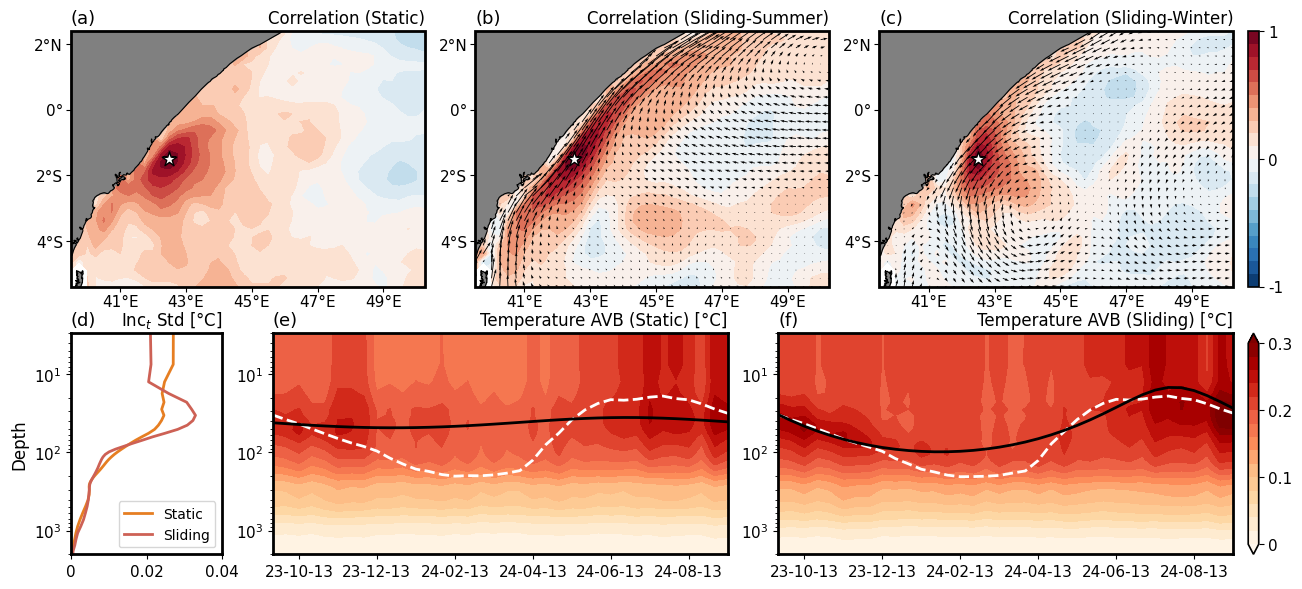

In [76]:
fig = plt.figure(figsize=(15, 7))
fig.subplots_adjust(hspace=0.12,wspace=1)
gs = GridSpec(2, 12, figure=fig,height_ratios=[1.3, 1])

ax00 = fig.add_subplot(gs[0, :4], projection=ccrs.PlateCarree())
ax00.add_feature(cfeature.LAND.with_scale('50m'),color='grey',zorder=2)
ax00.add_feature(cfeature.COASTLINE.with_scale('10m'),lw=0.8,zorder=2)
ax00.contourf(corr_cons.lon,corr_cons.lat,corr_cons.values,levels=np.linspace(-1,1,21),cmap='RdBu_r')
ax00.scatter(42.5,-1.5,c='w',s=120,marker='*',edgecolors='k')
gl00 =ax00.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
# gl00.left_labels = True
# gl00.bottom_labels = True
# gl00.xformatter = LONGITUDE_FORMATTER
# gl00.yformatter = LATITUDE_FORMATTER
# gl00.xlabel_style = {'size': 11}
# gl00.ylabel_style = {'size': 11}
lon_ticks = np.array([41,43,45,47,49])
lat_ticks = np.array([-4,-2,0,2])
ax00.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
ax00.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
ax00.xaxis.set_major_formatter(LONGITUDE_FORMATTER)
ax00.yaxis.set_major_formatter(LATITUDE_FORMATTER)
ax00.tick_params(axis='both', pad=2, labelsize=11, direction='out')
ax00.spines['geo'].set_linewidth(2)

ax01 = fig.add_subplot(gs[0, 4:8], projection=ccrs.PlateCarree())
ax01.add_feature(cfeature.LAND.with_scale('50m'),color='grey',zorder=2)
ax01.add_feature(cfeature.COASTLINE.with_scale('10m'),lw=0.8,zorder=2)
cs01 = ax01.contourf(corr_summer.lon,corr_summer.lat,corr_summer.values,levels=np.linspace(-1,1,21),cmap='RdBu_r')
q01 = ax01.quiver(u_summer_plot.lon,u_summer_plot.lat,u_summer_plot.uu,v_summer_plot.vv, scale_units='xy', scale=2)
ax01.quiverkey(q01, X=0.08, Y=0.95, U=1, label='1 m/s', 
               labelpos='E', coordinates='axes',zorder=2)
ax01.scatter(42.5,-1.5,c='w',s=120,marker='*',edgecolors='k')
gl01 =ax01.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
# gl01.left_labels = True
# gl01.bottom_labels = True
# gl01.xformatter = LONGITUDE_FORMATTER
# gl01.yformatter = LATITUDE_FORMATTER
# gl01.xlabel_style = {'size': 11}
# gl01.ylabel_style = {'size': 11}
lon_ticks = np.array([41,43,45,47,49])
lat_ticks = np.array([-4,-2,0,2])
ax01.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
ax01.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
ax01.xaxis.set_major_formatter(LONGITUDE_FORMATTER)
ax01.yaxis.set_major_formatter(LATITUDE_FORMATTER)
ax01.tick_params(axis='both', pad=2, labelsize=11, direction='out')
ax01.spines['geo'].set_linewidth(2)

ax02 = fig.add_subplot(gs[0, 8:], projection=ccrs.PlateCarree())
ax02.add_feature(cfeature.LAND.with_scale('50m'),color='grey',zorder=2)
ax02.add_feature(cfeature.COASTLINE.with_scale('10m'),lw=0.8,zorder=2)
cs02 = ax02.contourf(corr_winter.lon,corr_winter.lat,corr_winter.values,levels=np.linspace(-1,1,21),cmap='RdBu_r')
q02 = ax02.quiver(u_winter_plot.lon,u_winter_plot.lat,u_winter_plot.uu,v_winter_plot.vv, scale_units='xy', scale=2)
ax02.quiverkey(q02, X=0.08, Y=0.95, U=1, label='1 m/s', 
               labelpos='E', coordinates='axes',zorder=2)
ax02.scatter(42.5,-1.5,c='w',s=120,marker='*',edgecolors='k')
gl02 =ax02.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
# gl02.left_labels = True
# gl02.bottom_labels = True
# gl02.xformatter = LONGITUDE_FORMATTER
# gl02.yformatter = LATITUDE_FORMATTER
# gl02.xlabel_style = {'size': 11}
# gl02.ylabel_style = {'size': 11}
lon_ticks = np.array([41,43,45,47,49])
lat_ticks = np.array([-4,-2,0,2])
ax02.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
ax02.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
ax02.xaxis.set_major_formatter(LONGITUDE_FORMATTER)
ax02.yaxis.set_major_formatter(LATITUDE_FORMATTER)
ax02.tick_params(axis='both', pad=2, labelsize=11, direction='out')
ax02.spines['geo'].set_linewidth(2)

ax1 = fig.add_subplot(gs[1, 2:7])
ax1.contourf(np.arange(36),lev,diff_old.T,levels=np.linspace(0,.3,16),extend='both',cmap='OrRd')
ax1.plot(np.arange(36),td_old,c='w',lw=2,ls='--')
ax1.plot(np.arange(36),sin_fit(np.arange(36),lev[np.argmax(diff_old,1)]),c='k',lw=2)
ax1.set_yscale('log')
ax1.invert_yaxis() 
ax1.set_ylim(2000,3)
ax1.set_yticks([1000,100,10])
ax1.set_yticklabels(['10$^3$','10$^2$','10$^1$'],fontsize=11)
ax1.set_xlim(0,35)
ax1.set_xticks(np.arange(2,36,6))
ax1.set_xticklabels([date_list[i][2:] for i in np.arange(2,36,6,dtype='int')],fontsize=11)
# ax1.set_xlabel(f'Date',fontsize=12)
ax1.spines[['top','left','bottom','right']].set_linewidth(2)

ax2 = fig.add_subplot(gs[1, 7:])
cs2 = ax2.contourf(np.arange(36),lev,diff_new.T,levels=np.linspace(0,.3,16),extend='both',cmap='OrRd')
ax2.plot(np.arange(36),td_new,c='w',lw=2,ls='--')
ax2.plot(np.arange(36),sin_fit(np.arange(36),lev[np.argmax(diff_new,1)]),c='k',lw=2)
ax2.set_yscale('log')
ax2.invert_yaxis() 
ax2.set_ylim(2000,3)
ax2.set_yticks([1000,100,10])
ax2.set_yticklabels(['10$^3$','10$^2$','10$^1$'],fontsize=11)
ax2.set_xlim(0,35)
ax2.set_xticks(np.arange(2,36,6))
ax2.set_xticklabels([date_list[i][2:] for i in np.arange(2,36,6,dtype='int')],fontsize=11)
ax2.spines[['top','left','bottom','right']].set_linewidth(2)

ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(np.std(diff_old,0),lev,c=cr1,lw=2,label='Static')
ax3.plot(np.std(diff_new,0),lev,c=cr2,lw=2,label='Sliding')
ax3.set_yscale('log')
ax3.invert_yaxis() 
ax3.set_ylim(2000,3)
ax3.set_yticks([1000,100,10])
ax3.set_yticklabels(['10$^3$','10$^2$','10$^1$'],fontsize=11)
ax3.set_xlim(0.,0.04)
ax3.set_xticks([0.0,0.02,0.04])
ax3.set_xticklabels([0,0.02,0.04],fontsize=11)
ax3.set_ylabel('Depth',fontsize=12)
ax3.spines[['top','left','bottom','right']].set_linewidth(2)
ax3.legend(loc=4,fontsize=10)

cax = add_right_cax_big (ax02, ax02, pad=0.01, width=0.007)
cb =  fig.colorbar(cs01,cax=cax)
cb.set_ticks([-1,0,1])
cb.set_ticklabels([-1,0,1],fontsize=11)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(1.2)
cb.dividers.set_linewidth(1)

cax = add_right_cax_big (ax2, ax2, pad=0.01, width=0.007)
cb =  fig.colorbar(cs2,cax=cax)
cb.set_ticks([0,0.1,0.2,0.3])
cb.set_ticklabels([0,0.1,0.2,0.3],fontsize=11)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(1.2)
cb.dividers.set_linewidth(1)

ax00.set_title('(a)',fontsize=13,loc='left')
ax01.set_title('(b)',fontsize=13,loc='left')
ax02.set_title('(c)',fontsize=13,loc='left')

ax00.set_title('Correlation (Static)',fontsize=12,loc='right')
ax01.set_title('Correlation (Sliding-Summer)',fontsize=12,loc='right')
ax02.set_title('Correlation (Sliding-Winter)',fontsize=12,loc='right')

ax1.set_title('(e)',fontsize=13,loc='left')
ax2.set_title('(f)',fontsize=13,loc='left')
ax3.set_title('(d)',fontsize=13,loc='left')

ax1.set_title('Temperature AVB (Static) [°C]',fontsize=12,loc='right')
ax2.set_title('Temperature AVB (Sliding) [°C]',fontsize=12,loc='right')
ax3.set_title('Inc$_t$ Std [°C]',fontsize=12,loc='right')
fig_format = 'pdf'
fig.savefig('./PDF_fig/f02.' + fig_format, format=fig_format, dpi = 300, bbox_inches='tight')

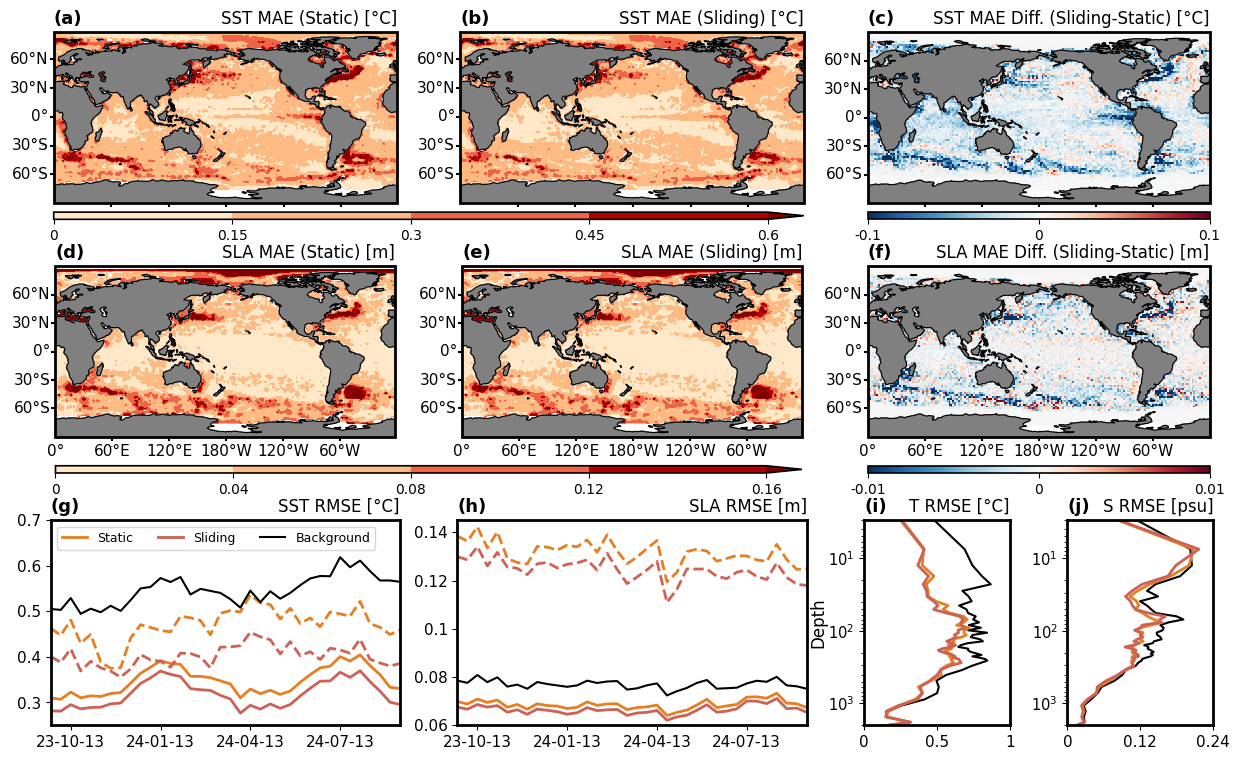

In [80]:
lon_ticks = np.arange(-180, 181, 60)
lat_ticks = np.arange(-90, 90, 30)[1:]

fig = plt.figure(figsize=(15, 9))
fig.subplots_adjust(hspace=0.5,wspace=1.3)
gs = GridSpec(4, 12, figure=fig,height_ratios=[1,1,-0.25,1.2])

ax00 = fig.add_subplot(gs[0, :4], projection=ccrs.PlateCarree(central_longitude=180))
ax00.add_feature(cfeature.LAND.with_scale('110m'),color='grey',zorder=2)
ax00.add_feature(cfeature.COASTLINE.with_scale('110m'),lw=0.8,zorder=2)
ax00.contourf(lon[::8],lat[::8],sst_mae_old_all[::8,::8],levels=np.linspace(0,0.6,5),cmap='OrRd',extend='max',transform=ccrs.PlateCarree())
gl00 =ax00.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
gl00.left_labels = True
gl00.xformatter = LONGITUDE_FORMATTER
gl00.yformatter = LATITUDE_FORMATTER
gl00.xlabel_style = {'size': 11}
gl00.ylabel_style = {'size': 11}
lon_ticks = np.array([60,120,180,240,300])
lat_ticks = np.array([-60,-30,0,30,60])
ax00.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
ax00.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
ax00.tick_params(axis='both', which='major', labelsize=0, length=3, width=1.5, direction='out')
ax00.spines['geo'].set_linewidth(2)

ax01 = fig.add_subplot(gs[0, 4:8], projection=ccrs.PlateCarree(central_longitude=180))
ax01.add_feature(cfeature.LAND.with_scale('110m'),color='grey',zorder=2)
ax01.add_feature(cfeature.COASTLINE.with_scale('110m'),lw=0.8,zorder=2)
cs01 = ax01.contourf(lon[::8],lat[::8],sst_mae_new_all[::8,::8],levels=np.linspace(0,0.6,5),cmap='OrRd',extend='max',transform=ccrs.PlateCarree())
gl01 =ax01.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
gl01.left_labels = True
gl01.xformatter = LONGITUDE_FORMATTER
gl01.yformatter = LATITUDE_FORMATTER
gl01.xlabel_style = {'size': 11}
gl01.ylabel_style = {'size': 11}
lon_ticks = np.array([60,120,180,240,300])
lat_ticks = np.array([-60,-30,0,30,60])
ax01.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
ax01.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
ax01.tick_params(axis='both', which='major', labelsize=0, length=3, width=1.5, direction='out')
ax01.spines['geo'].set_linewidth(2)

ax02 = fig.add_subplot(gs[0, 8:], projection=ccrs.PlateCarree(central_longitude=180))
ax02.add_feature(cfeature.LAND.with_scale('110m'),color='grey',zorder=2)
ax02.add_feature(cfeature.COASTLINE.with_scale('110m'),lw=0.8,zorder=2)
cs02 = ax02.pcolormesh(lon[::8],lat[::8],sst_mae_new_all[::8,::8] - sst_mae_old_all[::8,::8],vmin=-0.1,vmax=0.1,cmap='RdBu_r',transform=ccrs.PlateCarree())
gl02 =ax02.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
gl02.left_labels = True
gl02.xformatter = LONGITUDE_FORMATTER
gl02.yformatter = LATITUDE_FORMATTER
gl02.xlabel_style = {'size': 11}
gl02.ylabel_style = {'size': 11}
lon_ticks = np.array([60,120,180,240,300])
lat_ticks = np.array([-60,-30,0,30,60])
ax02.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
ax02.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
ax02.tick_params(axis='both', which='major', labelsize=0, length=3, width=1.5, direction='out')
ax02.spines['geo'].set_linewidth(2)

ax10 = fig.add_subplot(gs[1, :4], projection=ccrs.PlateCarree(central_longitude=180))
ax10.add_feature(cfeature.LAND.with_scale('110m'),color='grey',zorder=2)
ax10.add_feature(cfeature.COASTLINE.with_scale('110m'),lw=0.8,zorder=2)
ax10.contourf(lon[::8],lat[::8],sla_mae_old_all[::8,::8],levels=np.linspace(0,0.16,5),cmap='OrRd',extend='max',transform=ccrs.PlateCarree())
gl10 =ax10.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
gl10.left_labels = True
gl10.bottom_labels = True
gl10.xformatter = LONGITUDE_FORMATTER
gl10.yformatter = LATITUDE_FORMATTER
gl10.xlabel_style = {'size': 11}
gl10.ylabel_style = {'size': 11}
lon_ticks = np.array([60,120,180,240,300])
lat_ticks = np.array([-60,-30,0,30,60])
ax10.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
ax10.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
ax10.tick_params(axis='both', which='major', labelsize=0, length=3, width=1.5, direction='out')
ax10.spines['geo'].set_linewidth(2)

ax11 = fig.add_subplot(gs[1, 4:8], projection=ccrs.PlateCarree(central_longitude=180))
ax11.add_feature(cfeature.LAND.with_scale('110m'),color='grey',zorder=2)
ax11.add_feature(cfeature.COASTLINE.with_scale('110m'),lw=0.8,zorder=2)
cs11 = ax11.contourf(lon[::8],lat[::8],sla_mae_new_all[::8,::8],levels=np.linspace(0,0.16,5),cmap='OrRd',extend='max',transform=ccrs.PlateCarree())
gl11 =ax11.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
gl11.left_labels = True
gl11.bottom_labels = True
gl11.xformatter = LONGITUDE_FORMATTER
gl11.yformatter = LATITUDE_FORMATTER
gl11.xlabel_style = {'size': 11}
gl11.ylabel_style = {'size': 11}
lon_ticks = np.array([60,120,180,240,300])
lat_ticks = np.array([-60,-30,0,30,60])
ax11.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
ax11.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
ax11.tick_params(axis='both', which='major', labelsize=0, length=3, width=1.5, direction='out')
ax11.spines['geo'].set_linewidth(2)

ax12 = fig.add_subplot(gs[1, 8:], projection=ccrs.PlateCarree(central_longitude=180))
ax12.add_feature(cfeature.LAND.with_scale('110m'),color='grey',zorder=2)
ax12.add_feature(cfeature.COASTLINE.with_scale('110m'),lw=0.8,zorder=2)
cs12 = ax12.pcolormesh(lon[::8],lat[::8],sla_mae_new_all[::8,::8] - sla_mae_old_all[::8,::8],vmin=-0.01,vmax=0.01,cmap='RdBu_r',transform=ccrs.PlateCarree())
gl12 =ax12.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
gl12.left_labels = True
gl12.bottom_labels = True
gl12.xformatter = LONGITUDE_FORMATTER
gl12.yformatter = LATITUDE_FORMATTER
gl12.xlabel_style = {'size': 11}
gl12.ylabel_style = {'size': 11}
lon_ticks = np.array([60,120,180,240,300])
lat_ticks = np.array([-60,-30,0,30,60])
ax12.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
ax12.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
ax12.tick_params(axis='both', which='major', labelsize=0, length=3, width=1.5, direction='out')
ax12.spines['geo'].set_linewidth(2)

ax4 = fig.add_subplot(gs[3, :4])
ax4.plot(sst_rmse_old,c=cr1,lw=2,label='Static')
ax4.plot(sst_rmse_new,c=cr2,lw=2,label='Sliding')
ax4.plot(sst_rmse_old_mask,c=cr1,lw=2,ls='--')
ax4.plot(sst_rmse_new_mask,c=cr2,lw=2,ls='--')
ax4.plot(sst_rmse_b,'k',label='Background')
ax4.set_ylim(0.25,0.7)
ax4.set_yticks([0.3,0.4,0.5,0.6,0.7])
ax4.set_yticklabels([0.3,0.4,0.5,0.6,0.7],fontsize=11)
ax4.set_xlim(0,35)
ax4.set_xticks(np.arange(2,36,9))
ax4.set_xticklabels([date_list[i][2:] for i in np.arange(2,36,9,dtype='int')],fontsize=11)
ax4.legend(loc=2,ncol=3,fontsize=9)
ax4.spines[['top','left','bottom','right']].set_linewidth(2)

# ax4_in = inset_axes(ax4, width="38%", height="30%", loc='upper left', borderpad=0.5)
# ax4_in.pcolormesh(Land_mask[80:-80],vmin=0,vmax=2,cmap='Greys_r')
# ax4_in.pcolormesh(U_mask[80:-80],vmin=0,vmax=1.2,cmap='Reds')
# ax4_in.set_xticks([])
# ax4_in.set_yticks([])

ax5 = fig.add_subplot(gs[3, 4:8])
ax5.plot(sla_rmse_b,'k',label='Background')
ax5.plot(sla_rmse_old,c=cr1,lw=2,label='Static')
ax5.plot(sla_rmse_new,c=cr2,lw=2,label='Sliding')
ax5.plot(sla_rmse_old_mask,c=cr1,lw=2,ls='--')
ax5.plot(sla_rmse_new_mask,c=cr2,lw=2,ls='--')
ax5.set_ylim(0.06,0.145)
ax5.set_yticks([0.06,0.08,0.10,0.12,0.14])
ax5.set_yticklabels([0.06,0.08,0.10,0.12,0.14],fontsize=11)
ax5.set_xlim(0,35)
ax5.set_xticks(np.arange(2,36,9))
ax5.set_xticklabels([date_list[i][2:] for i in np.arange(2,36,9,dtype='int')],fontsize=11)
# ax5.legend(loc='center',ncol=3,fontsize=9)
ax5.spines[['top','left','bottom','right']].set_linewidth(2)

ax6 = fig.add_subplot(gs[3, 8:10])
ax6.plot(np.nanmean(t_rmse_b,0),lev,'k',label='Background')
ax6.plot(np.nanmean(t_rmse_old,0),lev,c=cr1,lw=2,label='Static')
ax6.plot(np.nanmean(t_rmse_new,0),lev,c=cr2,lw=2,label='Sliding')
ax6.set_yscale('log')
ax6.invert_yaxis() 
ax6.set_xlim(0.,1)
ax6.set_xticks([0.0,0.5,1])
ax6.set_xticklabels([0,0.5,1],fontsize=11)
ax6.set_ylim(2000,3)
ax6.set_yticks([1000,100,10])
ax6.set_yticklabels(['10$^3$','10$^2$','10$^1$'],fontsize=10.5)
ax6.set_ylabel('Depth',fontsize=12, labelpad=.5)
ax6.spines[['top','left','bottom','right']].set_linewidth(2)

ax7 = fig.add_subplot(gs[3, 10:])
ax7.plot(np.nanmean(s_rmse_b,0),lev,'k',label='Background')
ax7.plot(np.nanmean(s_rmse_old,0),lev,c=cr1,lw=2,label='Static')
ax7.plot(np.nanmean(s_rmse_new,0),lev,c=cr2,lw=2,label='Sliding')
ax7.set_yscale('log')
ax7.invert_yaxis() 
ax7.set_xlim(0.,0.24)
ax7.set_xticks([0.0,0.12,0.24])
ax7.set_xticklabels([0,0.12,0.24],fontsize=11)
ax7.set_ylim(2000,3)
ax7.set_yticks([1000,100,10])
ax7.set_yticklabels(['10$^3$','10$^2$','10$^1$'],fontsize=10.5)
ax7.spines[['top','left','bottom','right']].set_linewidth(2)

cax = add_bottom_cax_big (ax00, ax01, pad=0.01, width=0.008)
cb =  fig.colorbar(cs01,cax=cax,orientation='horizontal')
cb.set_ticks([0,0.15,0.3,0.45,0.6])
cb.set_ticklabels([0,0.15,0.3,0.45,0.6],fontsize=10)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(1.2)
cb.dividers.set_linewidth(1)

cax = add_bottom_cax_big (ax02, ax02, pad=0.01, width=0.008)
cb =  fig.colorbar(cs02,cax=cax,orientation='horizontal')
cb.set_ticks([-0.1, 0, 0.1])
cb.set_ticklabels([-0.1, 0, 0.1],fontsize=10)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(1.2)
cb.dividers.set_linewidth(1)

cax = add_bottom_cax_big (ax10, ax11, pad=0.032, width=0.008)
cb =  fig.colorbar(cs11,cax=cax,orientation='horizontal')
cb.set_ticks([0,0.04,0.08,0.12,0.16])
cb.set_ticklabels([0,0.04,0.08,0.12,0.16],fontsize=10)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(1.2)
cb.dividers.set_linewidth(1)

cax = add_bottom_cax_big (ax12, ax12, pad=0.032, width=0.008)
cb =  fig.colorbar(cs12,cax=cax,orientation='horizontal')
cb.set_ticks([-0.01,0,0.01])
cb.set_ticklabels([-0.01,0,0.01],fontsize=10)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(1.2)
cb.dividers.set_linewidth(1)

ax00.set_title('(a)',fontsize=13,loc='left',fontweight='bold')
ax01.set_title('(b)',fontsize=13,loc='left',fontweight='bold')
ax02.set_title('(c)',fontsize=13,loc='left',fontweight='bold')
ax10.set_title('(d)',fontsize=13,loc='left',fontweight='bold')
ax11.set_title('(e)',fontsize=13,loc='left',fontweight='bold')
ax12.set_title('(f)',fontsize=13,loc='left',fontweight='bold')

ax00.set_title('SST MAE (Static) [°C]',fontsize=12,loc='right')
ax01.set_title('SST MAE (Sliding) [°C]',fontsize=12,loc='right')
ax02.set_title('SST MAE Diff. (Sliding-Static) [°C]',fontsize=12,loc='right')
ax10.set_title('SLA MAE (Static) [m]',fontsize=12,loc='right')
ax11.set_title('SLA MAE (Sliding) [m]',fontsize=12,loc='right')
ax12.set_title('SLA MAE Diff. (Sliding-Static) [m]',fontsize=12,loc='right')

ax4.set_title('(g)',fontsize=13,loc='left',fontweight='bold')
ax5.set_title('(h)',fontsize=13,loc='left',fontweight='bold')
ax6.set_title('(i)',fontsize=13,loc='left',fontweight='bold')
ax7.set_title('(j)',fontsize=13,loc='left',fontweight='bold')
ax4.set_title('SST RMSE [°C]',fontsize=12,loc='right')
ax5.set_title('SLA RMSE [m]',fontsize=12,loc='right')
ax6.set_title('T RMSE [°C]',fontsize=12,loc='right')
ax7.set_title('S RMSE [psu]',fontsize=12,loc='right')
fig_format = 'pdf'
fig.savefig('./PDF_fig/f03.' + fig_format, format=fig_format, dpi = 300, bbox_inches='tight')

In [22]:
np.mean(sst_rmse_old - sst_rmse_new)/np.mean(sst_rmse_old), np.mean(sla_rmse_old - sla_rmse_new)/np.mean(sla_rmse_old)

(np.float64(0.08394288088511676), np.float64(0.031189102370711663))

In [23]:
np.mean(sst_rmse_old_mask - sst_rmse_new_mask)/np.mean(sst_rmse_old_mask), np.mean(sla_rmse_old_mask - sla_rmse_new_mask)/np.mean(sla_rmse_old_mask)

(np.float64(0.14501896678583648), np.float64(0.054753108661936306))

In [24]:
np.mean(sst_rmse_old_mask), np.mean(sst_rmse_new_mask)

(np.float64(0.4704673182799756), np.float64(0.4022406338765104))

In [25]:
np.mean(sla_rmse_old_mask), np.mean(sla_rmse_new_mask)

(np.float64(0.13159866603101092), np.float64(0.12439322997004908))

In [18]:
np.mean(sst_rmse_new), np.mean(sla_rmse_new)

(np.float64(0.31844600372844273), np.float64(0.06646003695039766))